
## Lab1_2: Seaborn (From Matplolib and pandas to seaborn)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Laboratorio_1.2
* Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galón.csv. Contruya el fit de al $95$ C.L.     



  



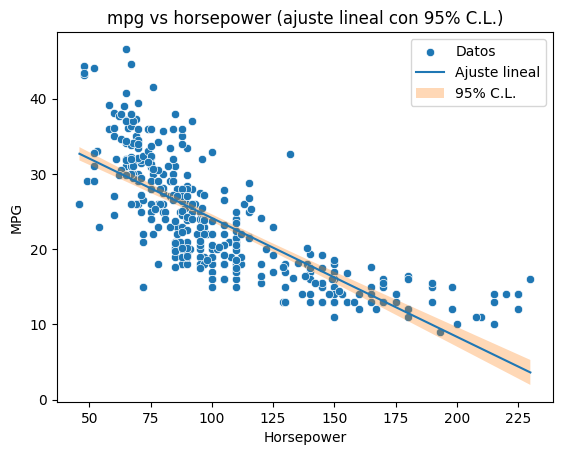

In [7]:
#Cargando datos
df = pd.read_csv("/content/drive/MyDrive/Física Computacional I 2026-1/Laboratorios/millas_por_galon.csv")

#Eligiendo las columnas
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df[['mpg', 'horsepower']].dropna()

#Variables
x = df['horsepower'].values
y = df['mpg'].values
n = len(x)

#Modelo y regresion lineal
def f(x, a, b):
    return a + b*x

#Ajuste
(a, b), _ = curve_fit(f, x, y)

#Nuevos valores con la regresion espaciados de a 100
x_pred = np.linspace(x.min(), x.max(), 100)
y_pred = f(x_pred, a, b)

#IC 95%
y_fit = f(x, a, b)
res = y - y_fit

sigma2 = np.sum(res**2) / (n - 2) #Varianza

x_mean = np.mean(x) #Media
Sxx = np.sum((x - x_mean)**2)

se = np.sqrt(sigma2 * (1/n + (x_pred - x_mean)**2 / Sxx))

y_up = y_pred + 1.96*se
y_down = y_pred - 1.96*se

#Gráficando ando
plt.figure()

# datos (seaborn)
sns.scatterplot(data=df, x='horsepower', y='mpg', label='Datos')

# ajuste
plt.plot(x_pred, y_pred, label='Ajuste lineal')

# banda 95%
plt.fill_between(x_pred, y_down, y_up, alpha=0.3, label='95% C.L.')

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('mpg vs horsepower (ajuste lineal con 95% C.L.)')
plt.legend()

plt.show()